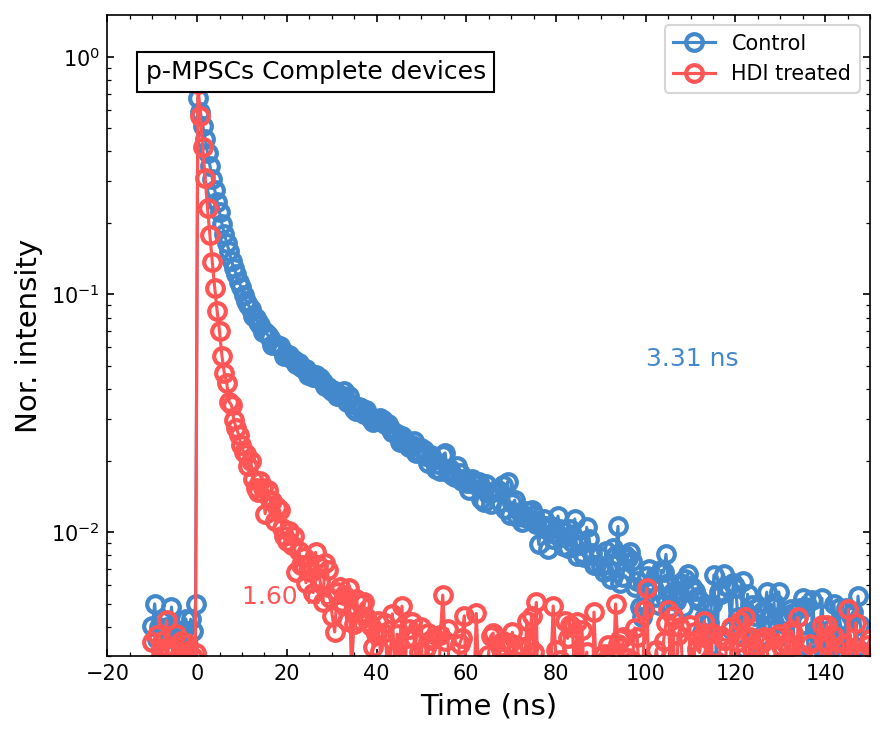

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
time = np.linspace(-10, 150, 300)

def decay(t, t1, a1, t2, a2):
    # Bi-exponential decay
    # t < 0: noise
    # t > 0: decay
    y = np.zeros_like(t)
    mask = t >= 0
    y[mask] = a1 * np.exp(-t[mask]/t1) + a2 * np.exp(-t[mask]/t2)
    # Add noise
    y += np.random.normal(0, 0.001, len(t))
    # Add baseline
    y += 0.003
    return y

# 1. HDI Treated (Red) - Fast
y_hdi = decay(time, 1.6, 0.8, 10, 0.05)
y_hdi[time < 0] = 0.003 + np.random.normal(0, 0.0005, np.sum(time < 0))

# 2. Control (Blue) - Slow
y_ctrl = decay(time, 3.31, 0.6, 30, 0.1)
y_ctrl[time < 0] = 0.004 + np.random.normal(0, 0.0005, np.sum(time < 0))

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Plots
ax.plot(time, y_ctrl, 'o-', color='#4488CC', mfc='none', markersize=8, mew=2, label='Control')
ax.plot(time, y_hdi, 'o-', color='#FF5555', mfc='none', markersize=8, mew=2, label='HDI treated')

# Labels
ax.text(10, 0.005, '1.60 ns', color='#FF5555', fontsize=12)
ax.text(100, 0.05, '3.31 ns', color='#4488CC', fontsize=12)

# Legend
ax.legend(frameon=True, loc='upper right', fontsize=10)
ax.text(0.05, 0.9, 'p-MPSCs Complete devices', transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

# Styling
ax.set_xlabel('Time (ns)', fontsize=14)
ax.set_ylabel('Nor. intensity', fontsize=14)
ax.set_yscale('log')
ax.set_ylim(0.003, 1.5)
ax.set_xlim(-20, 150)

# Ticks
ax.minorticks_on()
ax.tick_params(direction='in', top=True, right=True, which='both')

plt.tight_layout()
plt.show()
